In [ ]:
# ============================================================
# GGR376H5 Project Proposal Prelimary Analysis
# Week 01 — NO GeoPandas / NO GeoDataFrame
#
# Instructions:
# - There are 10 questions.
# - Each question has its own cell with TODO placeholders.
# - Immediately after each question, there is a TEST cell commented as # DO NOT CHANGE THIS CELL.
# - Do NOT edit the TEST cells at all; otherwise, you will receive ZERO for that question.
# - Your goal is to make every auto-test pass.
# - For each question, add 1-2 sentence interpretation of what the result means.
#
# Dataset(s): downloaded directly from the web (no manual files).
# ============================================================


In [ ]:
# STARTTTTTTT HEREEEE

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look clean
sns.set(style="whitegrid")

In [ ]:
# Load dataset from GitHun (Raw version) and read the csv file
df = pd.read_csv("https://raw.githubusercontent.com/seven143143/GGR376-Final-Project/main/newdiabetesdata.csv")

# View first 5 rows
df.head()

,FID,spatial_id,name,Raw Diabetes,Diabetes Percentage,CDName
0,0,5350001.0,"CT0001.00, Toronto, ON",44,7.7465,Toronto
1,1,5350002.0,"CT0002.00, Toronto, ON",91,12.0211,Toronto
2,2,5350003.0,"CT0003.00, Toronto, ON",27,2.5093,Toronto
3,3,5350004.0,"CT0004.00, Toronto, ON",600,9.7260,Toronto
4,4,5350005.0,"CT0005.00, Toronto, ON",346,4.5550,Toronto


In [ ]:
# Check dataset dimensions (rows, columns)
df.shape

# View column names
df.columns

# View data types and missing values
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065 entries, 0 to 1064
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   FID                  1065 non-null   int64  
 1   spatial_id           1065 non-null   float64
 2   name                 1065 non-null   object 
 3   Raw Diabetes         1065 non-null   int64  
 4   Diabetes Percentage  1065 non-null   float64
 5   CDName               1065 non-null   object 
dtypes: float64(2), int64(2), object(2)
memory usage: 50.1+ KB


In [ ]:
# check if there are any null values
df.isnull().sum()

# there are no null values

,0
FID,0
spatial_id,0
name,0
Raw Diabetes,0
Diabetes Percentage,0
CDName,0


In [ ]:
# Summary statistics for Diabetes Percentage

df["Diabetes Percentage"].describe()




,Diabetes Percentage
count,1065.000000
mean,7.765004
std,4.050697
min,0.000000
25%,4.404400
50%,7.820600
75%,10.751100
max,19.189200


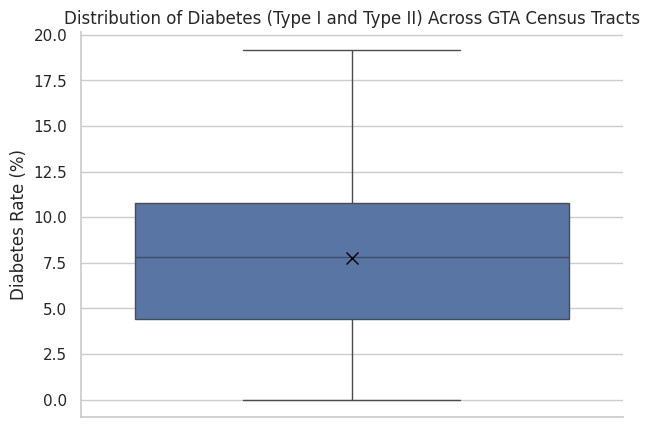

In [34]:
plt.figure(figsize=(7,5))

sns.boxplot(y=df["Diabetes Percentage"], color="#4C72B0", showmeans=True,
    meanprops={"marker": "x", "markeredgecolor": "black", "markersize": 8}
)

sns.despine()

plt.title("Distribution of Diabetes (Type I and Type II) Across GTA Census Tracts", fontsize=12)
plt.ylabel("Diabetes Rate (%)")
plt.xlabel("")

plt.show()

/tmp/ipykernel_447/3950286735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


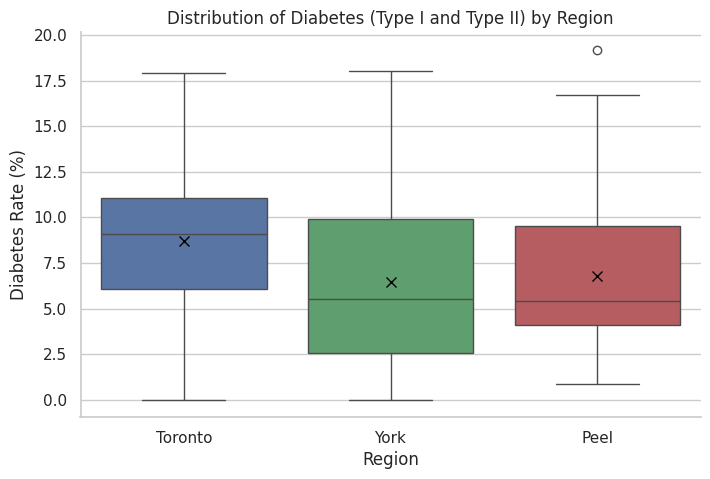

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(x="CDName", y="Diabetes Percentage", data=df,
palette=["#4C72B0", "#55A868", "#C44E52"], showmeans=True,
    meanprops={"marker": "x", "markeredgecolor": "black", "markersize": 7}
)

sns.despine()

plt.title("Distribution of Diabetes (Type I and Type II) by Region")
plt.xlabel("Region")
plt.ylabel("Diabetes Rate (%)")

plt.show()

In [36]:
df_summary = (
    df.groupby("CDName", as_index=False)
      .agg(
          n_tracts=("FID", "size"),
          mean_percentage=("Diabetes Percentage", "mean"),
          max_percentage=("Diabetes Percentage", "max"),
          median_percentage=("Diabetes Percentage", "median"),
      )
)


print("Summary output by Region")
print(type(df_summary))
try:
    display(df_summary)
except Exception as e:
    print("Could not display df_summary:", e)

Summary output by Region
<class 'pandas.core.frame.DataFrame'>


,CDName,n_tracts,mean_percentage,max_percentage,median_percentage
0,Peel,282,6.800154,19.1892,5.39735
1,Toronto,585,8.679399,17.9148,9.11230
2,York,198,6.437566,18.0485,5.54165
